# Examen final 

#### **Adrian Marcelo Ballesteros Herrera**

#### **750743**

___

#### Ejercicio 11

Activo: AAPL | Precio Actual: $298.87
Expiración seleccionada: 2026-05-20

--- Griegas Individuales: Bull Call Spread ---
Leg 1 (call K=297.5): Delta: 0.566, Theta: -0.370
Leg 2 (call K=305.0): Delta: 0.292, Theta: -0.306


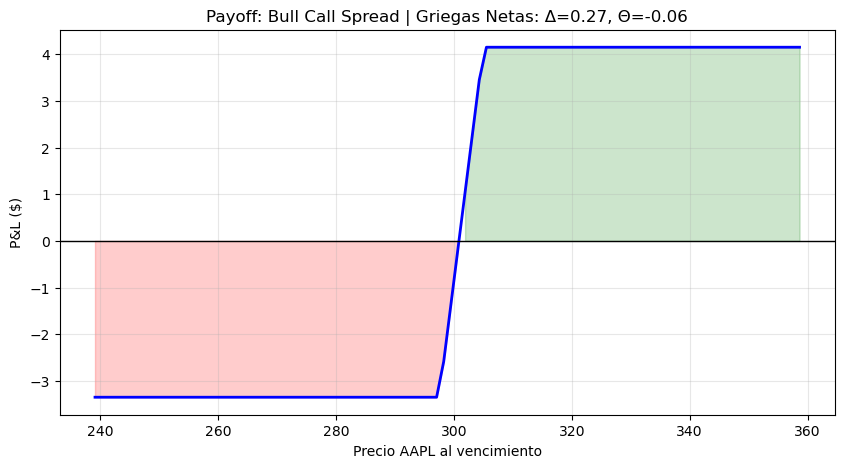

Griegas Netas del Portafolio: {'delta': np.float64(0.27490050021813506), 'gamma': np.float64(0.003676426129007468), 'vega': np.float64(0.01924631626381429), 'theta': np.float64(-0.0638490907982503)}
Máxima Ganancia: $4.15 | Máxima Pérdida: $-3.35

--- Griegas Individuales: Long Straddle ---
Leg 1 (call K=300.0): Delta: 0.471, Theta: -0.354
Leg 2 (put K=300.0): Delta: -0.533, Theta: -0.288


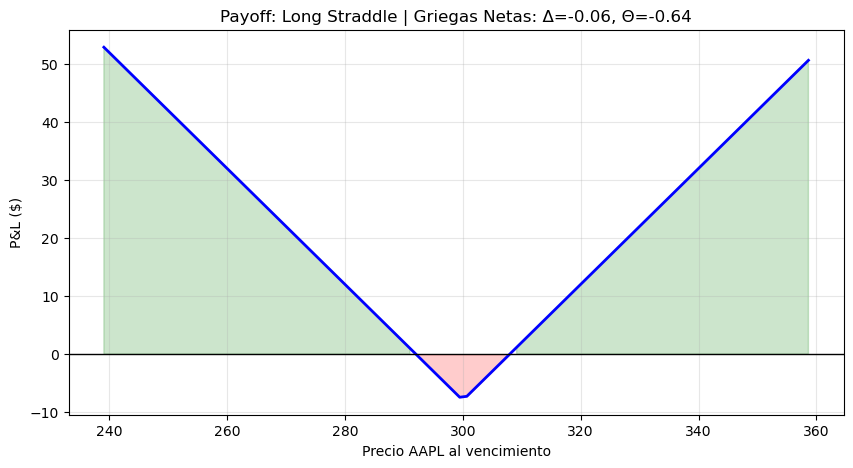

Griegas Netas del Portafolio: {'delta': np.float64(-0.06144541554358396), 'gamma': np.float64(0.08190898735032881), 'vega': np.float64(0.30482867507589173), 'theta': np.float64(-0.6419408056676297)}
Máxima Ganancia: $52.95 | Máxima Pérdida: $-7.42


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from datetime import datetime
# 1. Configuración y Descarga de Datos

ticker_symbol = "AAPL"
aapl = yf.Ticker(ticker_symbol)

# Obtener precio actual y cadena de opciones
S0 = aapl.history(period="1d")['Close'].iloc[-1]
expiraciones = aapl.options
fecha_exp = expiraciones[2] # Seleccionamos una fecha a ~1 mes
opt_chain = aapl.option_chain(fecha_exp)

print(f"Activo: {ticker_symbol} | Precio Actual: ${S0:.2f}")
print(f"Expiración seleccionada: {fecha_exp}")

# Parámetros Globales
r = 0.045  # Tasa libre de riesgo (aprox 4.5%)
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - datetime.now()).days / 365

# Funciones proporcionadas por el usuario (Griegas y Payoff)
def greeks(S, K, r, T, sigma, option='call'):
    if T <= 0 or sigma <= 0: return {k: 0 for k in ['delta','gamma','vega','theta']}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    if option == 'call':
        delta = norm.cdf(d1)
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta}

def payoff_estrategia(S_range, legs):
    total = np.zeros(len(S_range))
    for leg in legs:
        payoff = np.maximum(S_range - leg['K'], 0) if leg['tipo'] == 'call' else np.maximum(leg['K'] - S_range, 0)
        total += leg['posicion'] * (payoff - leg['prima'])
    return total

# 2. Selección de Contratos para Estrategias

# ESTRATEGIA A: Bull Call Spread (Compra Call ITM, Vende Call OTM)
call_itm = opt_chain.calls[opt_chain.calls['strike'] < S0].iloc[-1]
call_otm = opt_chain.calls[opt_chain.calls['strike'] > S0].iloc[2]

legs_bull = [
    {'tipo': 'call', 'K': call_itm['strike'], 'prima': call_itm['lastPrice'], 'posicion': 1, 'iv': call_itm['impliedVolatility']},
    {'tipo': 'call', 'K': call_otm['strike'], 'prima': call_otm['lastPrice'], 'posicion': -1, 'iv': call_otm['impliedVolatility']}
]

# ESTRATEGIA B: Long Straddle (Compra Call y Put ATM)
atm_call = opt_chain.calls.iloc[(opt_chain.calls['strike'] - S0).abs().argsort()[:1]].iloc[0]
atm_put = opt_chain.puts.iloc[(opt_chain.puts['strike'] - S0).abs().argsort()[:1]].iloc[0]

legs_straddle = [
    {'tipo': 'call', 'K': atm_call['strike'], 'prima': atm_call['lastPrice'], 'posicion': 1, 'iv': atm_call['impliedVolatility']},
    {'tipo': 'put', 'K': atm_put['strike'], 'prima': atm_put['lastPrice'], 'posicion': 1, 'iv': atm_put['impliedVolatility']}
]

# 3. Cálculo de Griegas y Visualización

S_range = np.linspace(S0 * 0.8, S0 * 1.2, 100)

def procesar_y_graficar(legs, nombre):
    pnl = payoff_estrategia(S_range, legs)
    
    # Cálculo de Griegas
    griegas_totales = {'delta': 0, 'gamma': 0, 'vega': 0, 'theta': 0}
    print(f"\n--- Griegas Individuales: {nombre} ---")
    for i, leg in enumerate(legs):
        g = greeks(S0, leg['K'], r, T, leg['iv'], leg['tipo'])
        for k in griegas_totales:
            griegas_totales[k] += g[k] * leg['posicion']
        print(f"Leg {i+1} ({leg['tipo']} K={leg['K']}): Delta: {g['delta']:.3f}, Theta: {g['theta']:.3f}")

    # Identificación de puntos clave
    costo_neto = sum(l['prima'] * l['posicion'] for l in legs)
    max_p = np.max(pnl)
    max_l = np.min(pnl)
    
    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, pnl, label='Payoff al Vencimiento', color='blue', lw=2)
    plt.axhline(0, color='black', lw=1)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.2, color='green')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.2, color='red')
    plt.title(f"Payoff: {nombre} | Griegas Netas: Δ={griegas_totales['delta']:.2f}, Θ={griegas_totales['theta']:.2f}")
    plt.xlabel("Precio AAPL al vencimiento")
    plt.ylabel("P&L ($)")
    plt.grid(alpha=0.3)
    plt.show()
    
    print(f"Griegas Netas del Portafolio: {griegas_totales}")
    print(f"Máxima Ganancia: ${max_p:.2f} | Máxima Pérdida: ${max_l:.2f}")

procesar_y_graficar(legs_bull, "Bull Call Spread")
procesar_y_graficar(legs_straddle, "Long Straddle")

- El Bull Call Spread lo compraria si se espera una subida, pero no avismal, si no muy controlada o moderada en el mercado, esto tiene sentido con el resultado de delta siendo positivo, es que gana valor mientras suba el precio y la theta es negativa por que tiene una relacion negativa con el tiempo, cada dia que pase se devalua mas nuestra opcion.

- El Long Straddle si sabemos que el mercado esta muy volatil pero no sabemos en que direccion va a ir, su relacion con vega es positiva por que si aumenta la volatilidad, nosotros ganamos dinero, y theta muy alto por que tu compraste el call y el put por lo que el tiempo te esta deteriorando de forma fuerte tu estrategia de trading




___

#### Ejercicio 12


                        Precio MC Real
Call Europea (BS Ref)        5.001542
Put Europea                 18.965255
Call Asiática                1.443420
Call Barrier (U&O)           2.326542


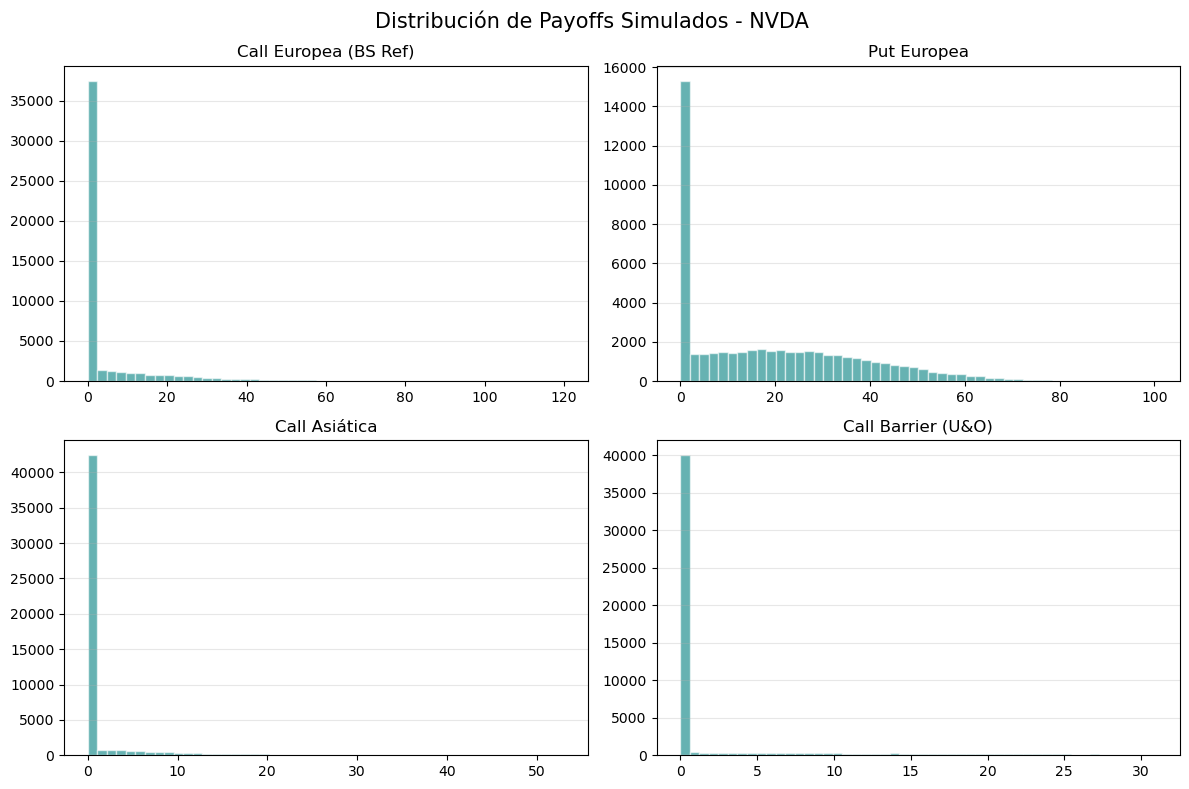

In [9]:
# 1. Obtener precio actual (S0)
nvda = yf.Ticker("NVDA")
S0 = nvda.history(period="1d")['Close'].iloc[-1]

# 2. Obtener cadena de opciones y seleccionar vencimiento (~3 meses)
expiraciones = nvda.options
fecha_exp = expiraciones[3] # Aproximadamente 90 días
opt_chain = nvda.option_chain(fecha_exp)

# 3. Seleccionar un Strike (K) ligeramente OTM
# Buscamos el primer strike que sea al menos 5% mayor al precio actual
K = opt_chain.calls[opt_chain.calls['strike'] > S0 * 1.05]['strike'].iloc[0]
volatilidad_mercado = opt_chain.calls[opt_chain.calls['strike'] == K]['impliedVolatility'].iloc[0]

# 4. Calcular tiempo al vencimiento (T)
dias_al_vencimiento = (datetime.strptime(fecha_exp, '%Y-%m-%d') - datetime.now()).days
T = dias_al_vencimiento / 365

# 5. Obtener Tasa Libre de Riesgo (r) usando el Treasury Bill de 13 semanas (^IRX)
tnx = yf.Ticker("^IRX")
r = tnx.history(period="1d")['Close'].iloc[-1] / 100 

# 6. Definir Barrera (B) dinámicamente (20% arriba del Spot)
B = S0 * 1.20

# Parámetros de simulación
num_simulations = 50000
num_steps = dias_al_vencimiento
dt = T / num_steps
discount = np.exp(-r * T)

# Simulación de Caminos
Z = np.random.standard_normal((num_steps, num_simulations))
log_returns = (r - 0.5 * volatilidad_mercado**2) * dt + volatilidad_mercado * np.sqrt(dt) * Z
paths = np.zeros((num_steps + 1, num_simulations))
paths[0] = S0
for t in range(1, num_steps + 1):
    paths[t] = paths[t-1] * np.exp(log_returns[t-1])

# Cálculo de Payoffs
ST = paths[-1]
payoff_call_euro = np.maximum(ST - K, 0)
payoff_put_euro = np.maximum(K - ST, 0)
payoff_call_asian = np.maximum(np.mean(paths, axis=0) - K, 0)

# Up-and-Out Barrier: Si en cualquier punto toca B, el payoff es 0
hit_barrier = np.any(paths >= B, axis=0)
payoff_call_barrier = np.where(hit_barrier, 0, payoff_call_euro)

# Precios Finales
precios = {
    "Call Europea (BS Ref)": payoff_call_euro.mean() * discount,
    "Put Europea": payoff_put_euro.mean() * discount,
    "Call Asiática": payoff_call_asian.mean() * discount,
    "Call Barrier (U&O)": payoff_call_barrier.mean() * discount
}

# Mostrar Tabla
df_precios = pd.DataFrame.from_dict(precios, orient='index', columns=['Precio MC Real'])
print("\n", df_precios)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
payoffs = [payoff_call_euro, payoff_put_euro, payoff_call_asian, payoff_call_barrier]
titles = list(precios.keys())

for i, ax in enumerate(axes.flatten()):
    ax.hist(payoffs[i], bins=50, color='teal', alpha=0.6, edgecolor='white')
    ax.set_title(titles[i])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f"Distribución de Payoffs Simulados - NVDA ", fontsize=15)
plt.tight_layout()
plt.show()

En las opciones asiaticas al promediar los precios, la volatilidad efectiva del payoff disminuye, por lo que menor volatilidad, menor precio de la prima (1.44)

Y en la opcion Up y Out es mas barata que las demas por que al comprar esta, tienes el riesgo que si llega a esta barrera, muere directamente tu opcion (2.32)
